In [1]:
import pandas as pd

In [7]:
df = pd.read_csv('../../bronze/atletas_por_sexo.csv')

In [8]:
df_genero = df.groupby(
    ['edition', 'country_noc', 'sexo']
)['athlete_id'].nunique().unstack(fill_value=0)

In [9]:
df_genero = df_genero.rename(columns={
    'Men': 'male_athletes',
    'Women': 'female_athletes'
})

In [10]:
df_genero['total_athletes'] = df_genero.sum(axis=1)
df_genero = df_genero.reset_index()

In [6]:
df_genero

sexo,edition,country_noc,male_athletes,Mixed,Open,female_athletes,total_athletes
0,1896 Summer Olympics,AUS,1,0,0,0,1
1,1896 Summer Olympics,AUT,3,0,0,0,3
2,1896 Summer Olympics,DEN,2,0,0,0,2
3,1896 Summer Olympics,FRA,7,0,0,0,7
4,1896 Summer Olympics,GBR,8,0,0,0,8
...,...,...,...,...,...,...,...
1876,2024 Summer Olympics,UGA,1,0,0,1,2
1877,2024 Summer Olympics,UKR,6,0,0,9,15
1878,2024 Summer Olympics,USA,120,0,0,145,265
1879,2024 Summer Olympics,UZB,11,0,0,2,13


In [11]:
df_genero.to_csv('../analise_genero/genero_summary.csv', index=False)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [35]:
def plot_top50_genero(df, titulo, nome_arquivo):

    plt.style.use('seaborn-v0_8-whitegrid')

    os.makedirs("../analise_genero", exist_ok=True)

    data = df.groupby('country_noc')[
        ['male_athletes', 'female_athletes']
    ].sum()

    data['total'] = data.sum(axis=1)

    data = data.sort_values(by='total', ascending=False).head(50)
    data = data.sort_values(by='total', ascending=True)

    y = np.arange(len(data))

    plt.figure(figsize=(12, 14))

    plt.barh(y, data['male_athletes'], color='#1f77b4', label='Homens')
    plt.barh(y, data['female_athletes'], left=data['male_athletes'], color='#ff69b4', label='Mulheres')

    plt.yticks(y, data.index)

    plt.margins(y=0)
    plt.ylim(-0.5, len(data) - 0.5)

    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.xlabel('Quantidade de Atletas')
    plt.ylabel('País (NOC)')

    plt.legend(title="Sexo")
    plt.tight_layout()
    plt.savefig("../analise_genero/top_50_paises_atletas_genero.png", dpi=300, bbox_inches='tight')
    plt.show()

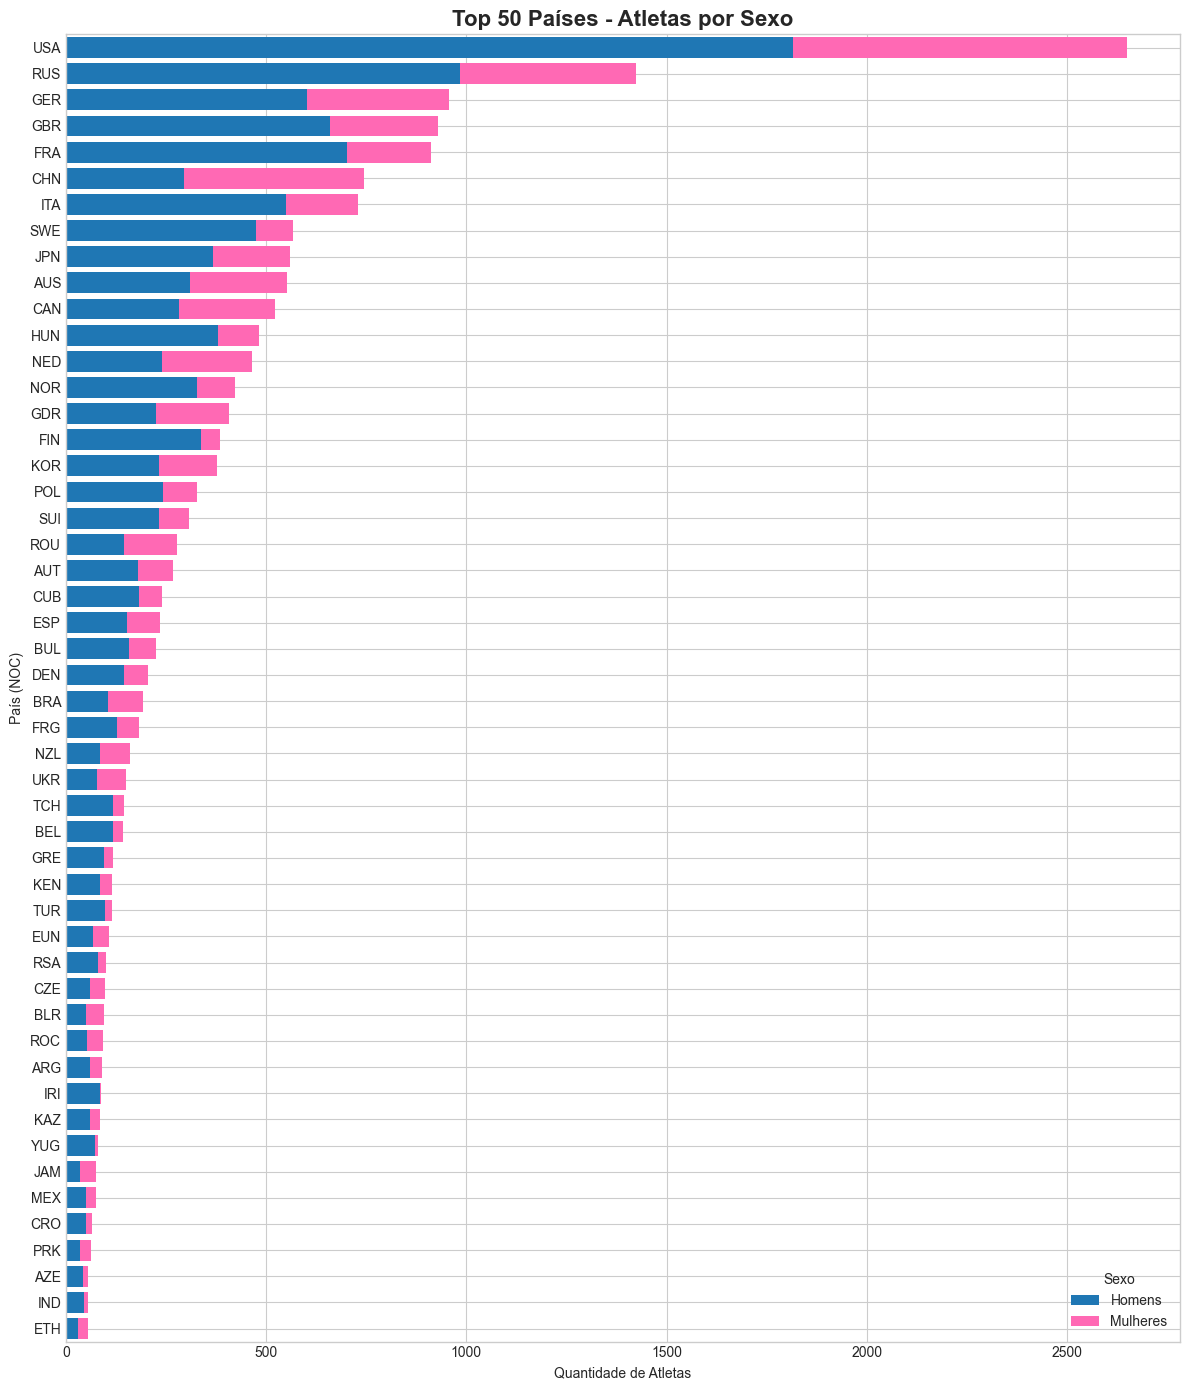

In [36]:
plot_top50_genero(
    df_genero,
    'Top 50 Países - Atletas por Sexo',
    'genero_plot.png'
)

In [25]:
totais = df_genero[
    ['male_athletes', 'female_athletes', 'Mixed', 'Open']
].sum()

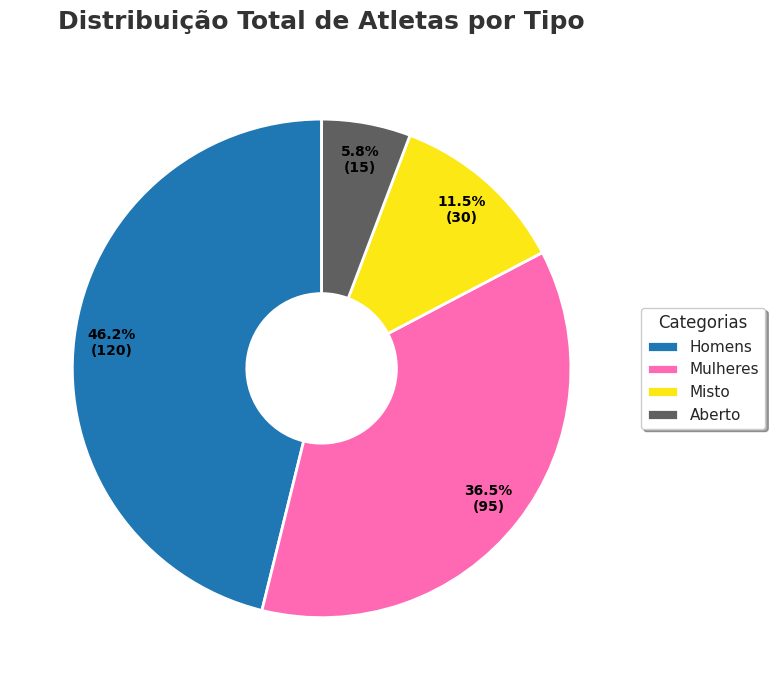

In [ ]:
# Seus dados (substitua pelos seus)
totais = [120, 95, 30, 15]  # exemplo: Homens, Mulheres, Misto, Aberto
labels = ['Homens', 'Mulheres', 'Misto', 'Aberto']

# Cores personalizadas (paleta suave e moderna)
cores = ["#1f77b4", "#ff69b4", "#fbe814", "#606060"]  # azul, laranja, azul claro, vermelho
# Você também pode usar uma paleta do seaborn:
# import seaborn as sns
# cores = sns.color_palette("pastel", len(labels))

# Função para formatar os valores com percentual e número absoluto
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format

# Configurar figura
plt.figure(figsize=(9, 7))
plt.rcParams['font.family'] = 'DejaVu Sans'  # ou 'Arial', 'Helvetica'

# Criar o gráfico de rosca (donut)
wedges, texts, autotexts = plt.pie(
    totais,
    labels=None,               # removemos os labels diretos no gráfico
    colors=cores,
    autopct=autopct_format(totais),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.7},  # width 0.7 cria o efeito rosca
    pctdistance=0.85,          # distância dos percentuais do centro
    textprops={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'},
)

# Adicionar legenda personalizada (mais elegante)
plt.legend(
    wedges, labels,
    title="Categorias",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    edgecolor='#cccccc'
)

# Título principal
plt.title(
    'Distribuição Total de Atletas por Tipo',
    fontsize=18,
    fontweight='bold',
    pad=20,
    color='#333333'
)

plt.tight_layout()
plt.savefig("../analise_genero/genero_geral_pizza.png", dpi=300, bbox_inches='tight')
plt.show()